<table>
    <tr>
    <th>
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">basophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left;">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">erythroblast</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">immature</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">4</th>
                <th  style="font-size:150%;text-align:left;">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">5</th>
                <th  style="font-size:150%;text-align:left;">monocyte</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">6</th>
                <th  style="font-size:150%;text-align:left;">neutrophil</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">7</th>
                <th  style="font-size:150%;text-align:left">platelet</th>
            </tr>            
        </table>
    </th>
    <th>     
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>        
        <img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/bloodMNIST8.png" width="512">
    </th>
    </tr>
</table>   

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://github.com/MedMNIST/MedMNIST/tree/main">Veuillez vous référer à la page Github officielle pour plus de détails.</a></div>

>> **site du projet** : https://medmnist.com/

>> **site de données** : https://zenodo.org/records/10519652


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [1]:
#!pip install tensorflow keras

In [2]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ['KERAS_BACKEND'] = 'tensorflow'
# os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
# os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [3]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 :
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')

sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.20.0	CUDA True	GPU True	XLA True
Keras      : 3.10.0
Pandas     : 2.2.2
NumPy      : 2.0.2


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [4]:
import gdown

!rm -Rf outils
!mkdir outils
file_id = "1uXKdCay7j-cXVrwhEoA1U1Fyi7L5d5cc"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "outils/configModele.py", quiet=False)

file_id = "1SGQZCroLlUE7oBYGJEPv97fz2HUwlAAr"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "outils/configProjet.py", quiet=False)

!rm -Rf donnees
!mkdir -p donnees/BloodMNIST/apprentissage
!mkdir -p donnees/BloodMNIST/validation

file_id = "1qr44r3bRY-SHI7ZimG-72Kw7vJQiqvas"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "donnees/BloodMNIST/validation/validation.tfrecords", quiet=False)

file_id = "1GGwqEm7sW__4rvg8SNx6fHJewGgk328S"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "donnees/BloodMNIST/apprentissage/apprentissage.tfrecords", quiet=False)

file_id = "1IPO-S9Z_Ok0I-AdiWhSEosfNxlayVHl0"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "donnees/BloodMNIST/dictLabels", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1uXKdCay7j-cXVrwhEoA1U1Fyi7L5d5cc
From (redirected): https://drive.google.com/uc?id=1uXKdCay7j-cXVrwhEoA1U1Fyi7L5d5cc&confirm=t&uuid=35edae50-69f4-48fa-b201-4cfa234c7ca4
To: /content/outils/configModele.py
100%|██████████| 28.7k/28.7k [00:00<00:00, 69.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1SGQZCroLlUE7oBYGJEPv97fz2HUwlAAr
From (redirected): https://drive.google.com/uc?id=1SGQZCroLlUE7oBYGJEPv97fz2HUwlAAr&confirm=t&uuid=2831a4ed-2d32-4e26-b6b2-fbd7517def75
To: /content/outils/configProjet.py
100%|██████████| 11.3k/11.3k [00:00<00:00, 35.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qr44r3bRY-SHI7ZimG-72Kw7vJQiqvas
To: /content/donnees/BloodMNIST/validation/validation.tfrecords
100%|██████████| 4.04M/4.04M [00:00<00:00, 114MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GGwqEm7sW__4rvg8SNx6fHJewGgk328S
To: /content/donnees/BloodMNIST/apprentissage/apprentissage.tfrecord

'donnees/BloodMNIST/dictLabels'

In [5]:
!ls -al outils
!ls -al donnees/BloodMNIST/*/*

total 52
drwxr-xr-x 2 root root  4096 Sep 11 18:28 .
drwxr-xr-x 1 root root  4096 Sep 11 18:28 ..
-rw-r--r-- 1 root root 28684 Sep 11 17:31 configModele.py
-rw-r--r-- 1 root root 11334 Sep 11 17:31 configProjet.py
-rw-r--r-- 1 root root 16116020 Sep  7 06:14 donnees/BloodMNIST/apprentissage/apprentissage.tfrecords
-rw-r--r-- 1 root root  4035433 Sep  7 06:14 donnees/BloodMNIST/validation/validation.tfrecords


In [6]:
sys.path.append(os.path.abspath('outils/'))

In [7]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [8]:
from configProjet import palette, initParametresProjet
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [9]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelPersonalise

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [10]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(28, 28, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire='donnees/BloodMNIST',
                            cycle_length=None,
                            deterministic=None,
                            repetition=1,
                            bufferAleatoire=1024)

In [11]:
print(f"""
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  image_size    = (28, 28, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 8
  dictLabels    = {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

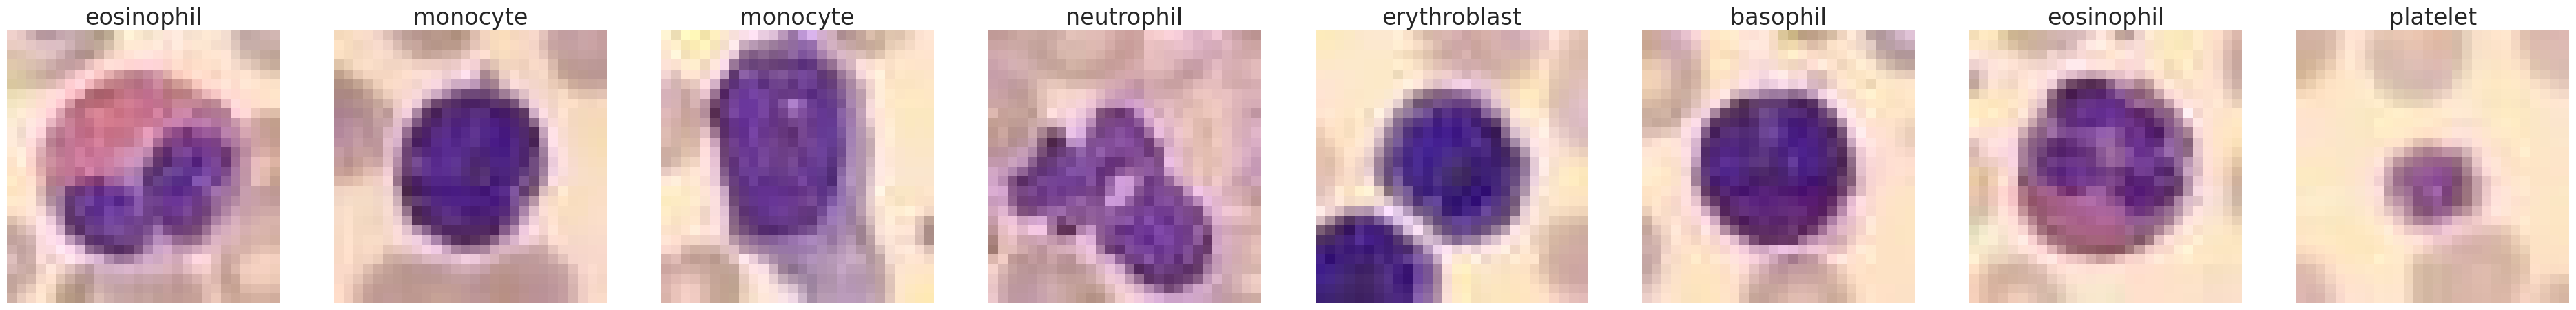

In [12]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

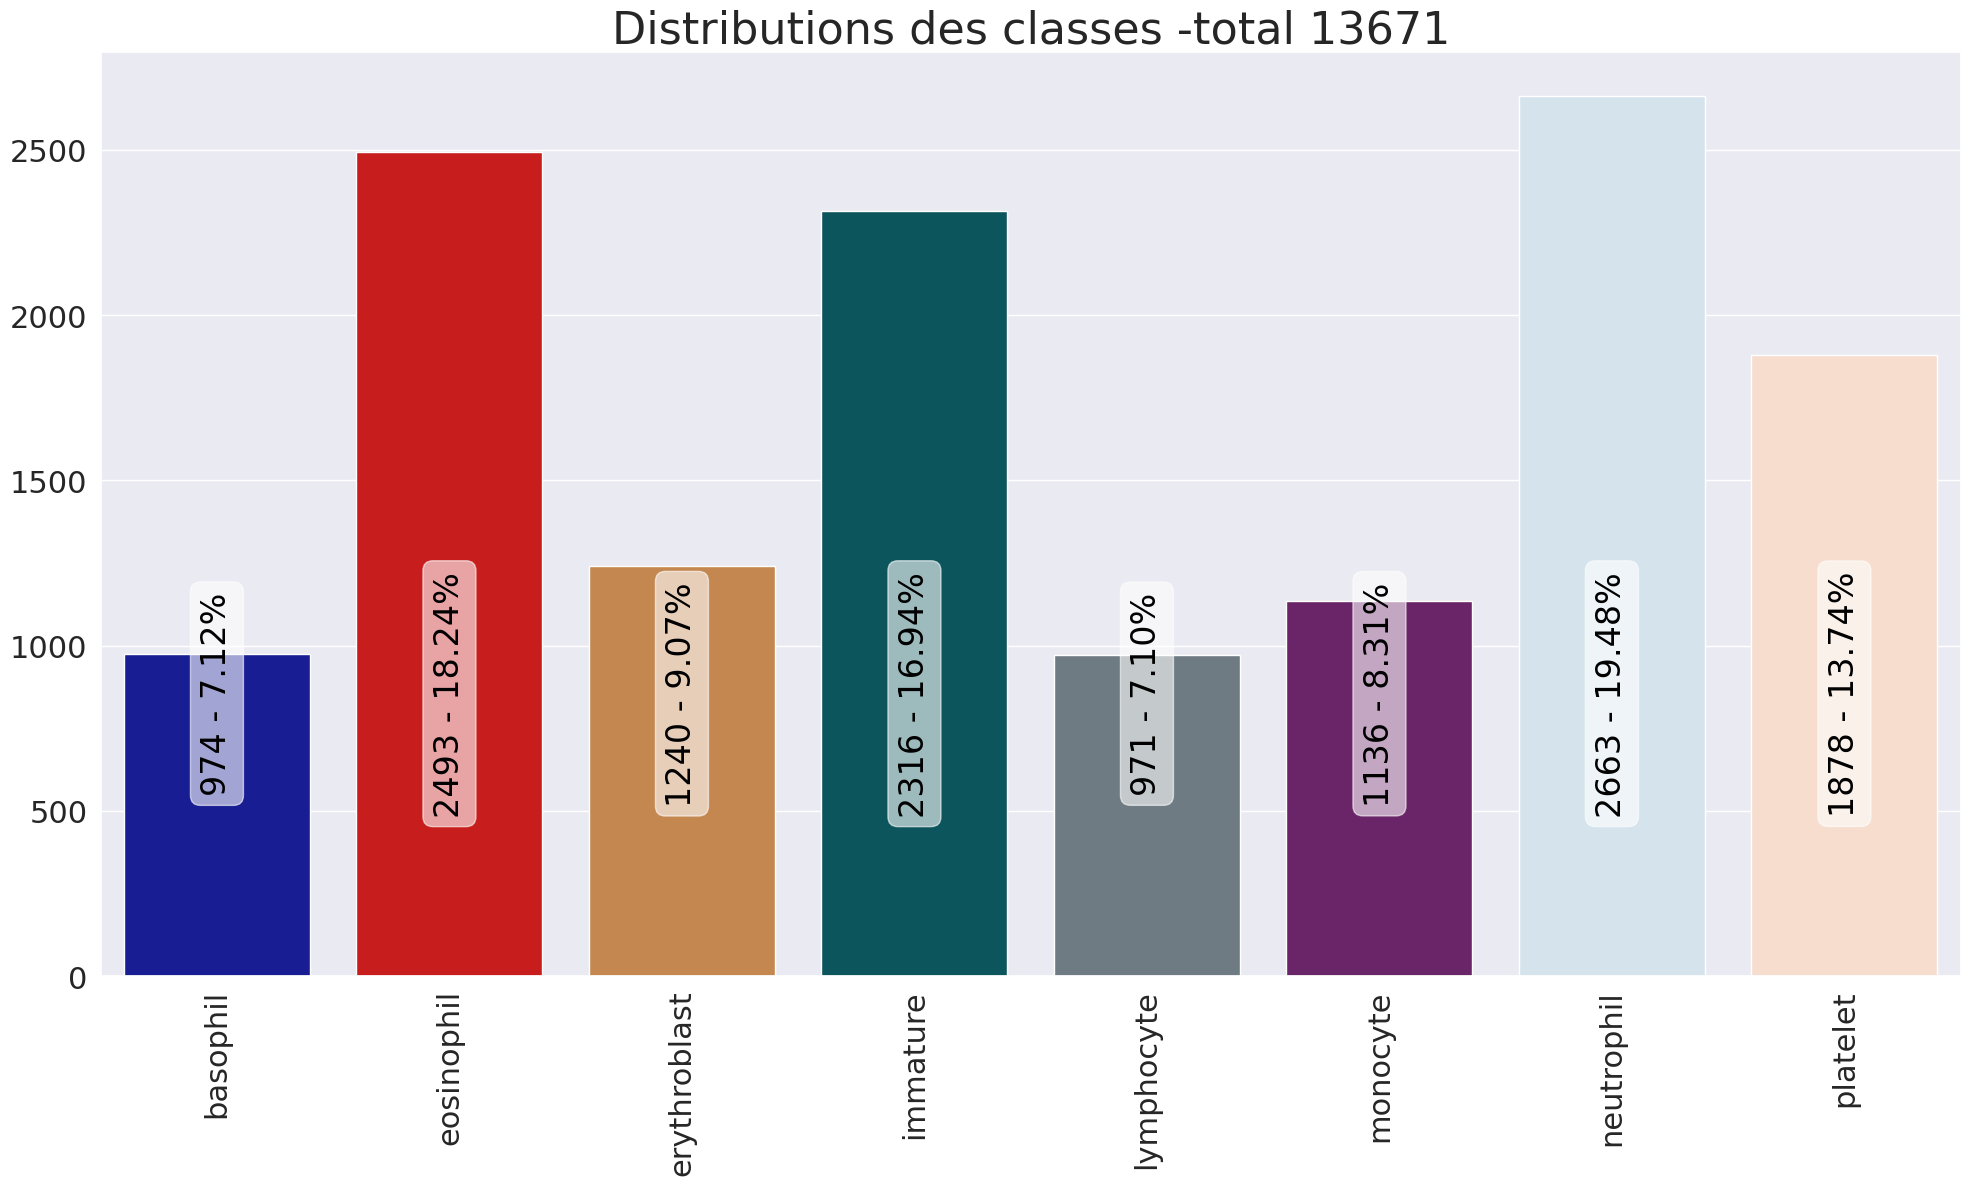

In [13]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>

In [14]:
nomModel = 'CNN-PersonaliseMNIST'

In [15]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"0.1-bloodMNIST-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='../ResultatsExecutions')

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Conception du modèle</div></b>

In [16]:
def modelCNNSimple(image_size,
                   num_classes,
                   activation,
                   nb_filtres):

    preprocessData = tf.keras.Sequential([
            keras.layers.Rescaling(1.0 / 255),
        ])

    inputs = keras.Input(shape=image_size)

    # Entry block
    x = keras.layers.Conv2D(nb_filtres, kernel_size=(3,3), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(inputs)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres, kernel_size=(1,1), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres, kernel_size=(3,3), strides=(2,2), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(1,1), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(3,3), strides=(1,1), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.Conv2D(nb_filtres//2, kernel_size=(3,3), strides=(2,2), padding="same",kernel_initializer='glorot_normal')(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)

    x = keras.layers.GlobalAveragePooling2D()(x)

    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name='ModelPersonaliseMNIST')

In [17]:
model = modelCNNSimple(image_size=image_size,
                       num_classes=nombreClasses,
                       activation=keras.ops.gelu,
                       nb_filtres = 32)

In [18]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

In [19]:
model.summary()

Model: "ModelPersonaliseMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 16)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 16)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 16)       │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 16,936 (66.16 KB)

 Trainable params: 16,648 (65.03 KB)

 Non-trainable params: 288 (1.12 KB)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [20]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-04,
                               max_lrate=1e-04,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

filename = os.path.join(repertoireModelSauvegarde, 'modelVLoss.keras')
learningRate = keras.callbacks.LearningRateScheduler(evolutionTauxApprentissage)
checkpointLoss = keras.callbacks.ModelCheckpoint(filename,
                                                    monitor = 'val_loss',
                                                    verbose = 1,
                                                    save_best_only = True,
                                                    mode = 'min')

backupAndRestore = keras.callbacks.BackupAndRestore(backup_dir=repertoireModelCKP)
tensorBoard = keras.callbacks.TensorBoard(log_dir=repertoireModelLogs)

arretPrecoce = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, verbose=1)

callbacks = [learningRate,checkpointLoss,backupAndRestore,tensorBoard,arretPrecoce]

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

L'évolution du taux d'apprentissage : du 0.001 à 8.61e-05


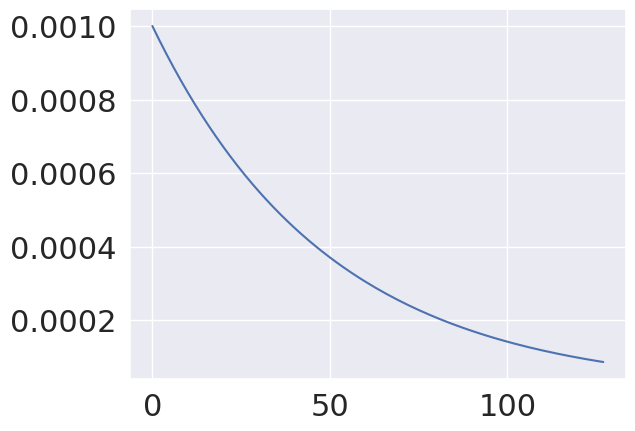

In [21]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [22]:
historiqueApprentissage, model = entrainementModele( model,
                                                     pipelineApprentissage,
                                                     pipelineValidation,
                                                     epochs,
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2,
                                                     repertoireModelSauvegarde)

Epoch 1/128

Epoch 1: val_loss improved from inf to 1.46280, saving model to ../ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
428/428 - 12s - 28ms/step - accuracy: 0.5980 - loss: 1.2733 - val_accuracy: 0.5115 - val_loss: 1.4628 - learning_rate: 1.0000e-03
Epoch 2/128

Epoch 2: val_loss improved from 1.46280 to 1.07379, saving model to ../ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
428/428 - 9s - 21ms/step - accuracy: 0.7161 - loss: 0.8736 - val_accuracy: 0.5925 - val_loss: 1.0738 - learning_rate: 9.8020e-04
Epoch 3/128

Epoch 3: val_loss did not improve from 1.07379
428/428 - 9s - 21ms/step - accuracy: 0.7503 - loss: 0.7548 - val_accuracy: 0.6115 - val_loss: 1.1404 - learning_rate: 9.6080e-04
Epoch 4/128

Epoch 4: val_loss improved from 1.07379 to 0.70179, saving model to ../ResultatsExecutions/0.1-bloodMNIST-CNN-PersonaliseMNIST-bs32-epochs128

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [23]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

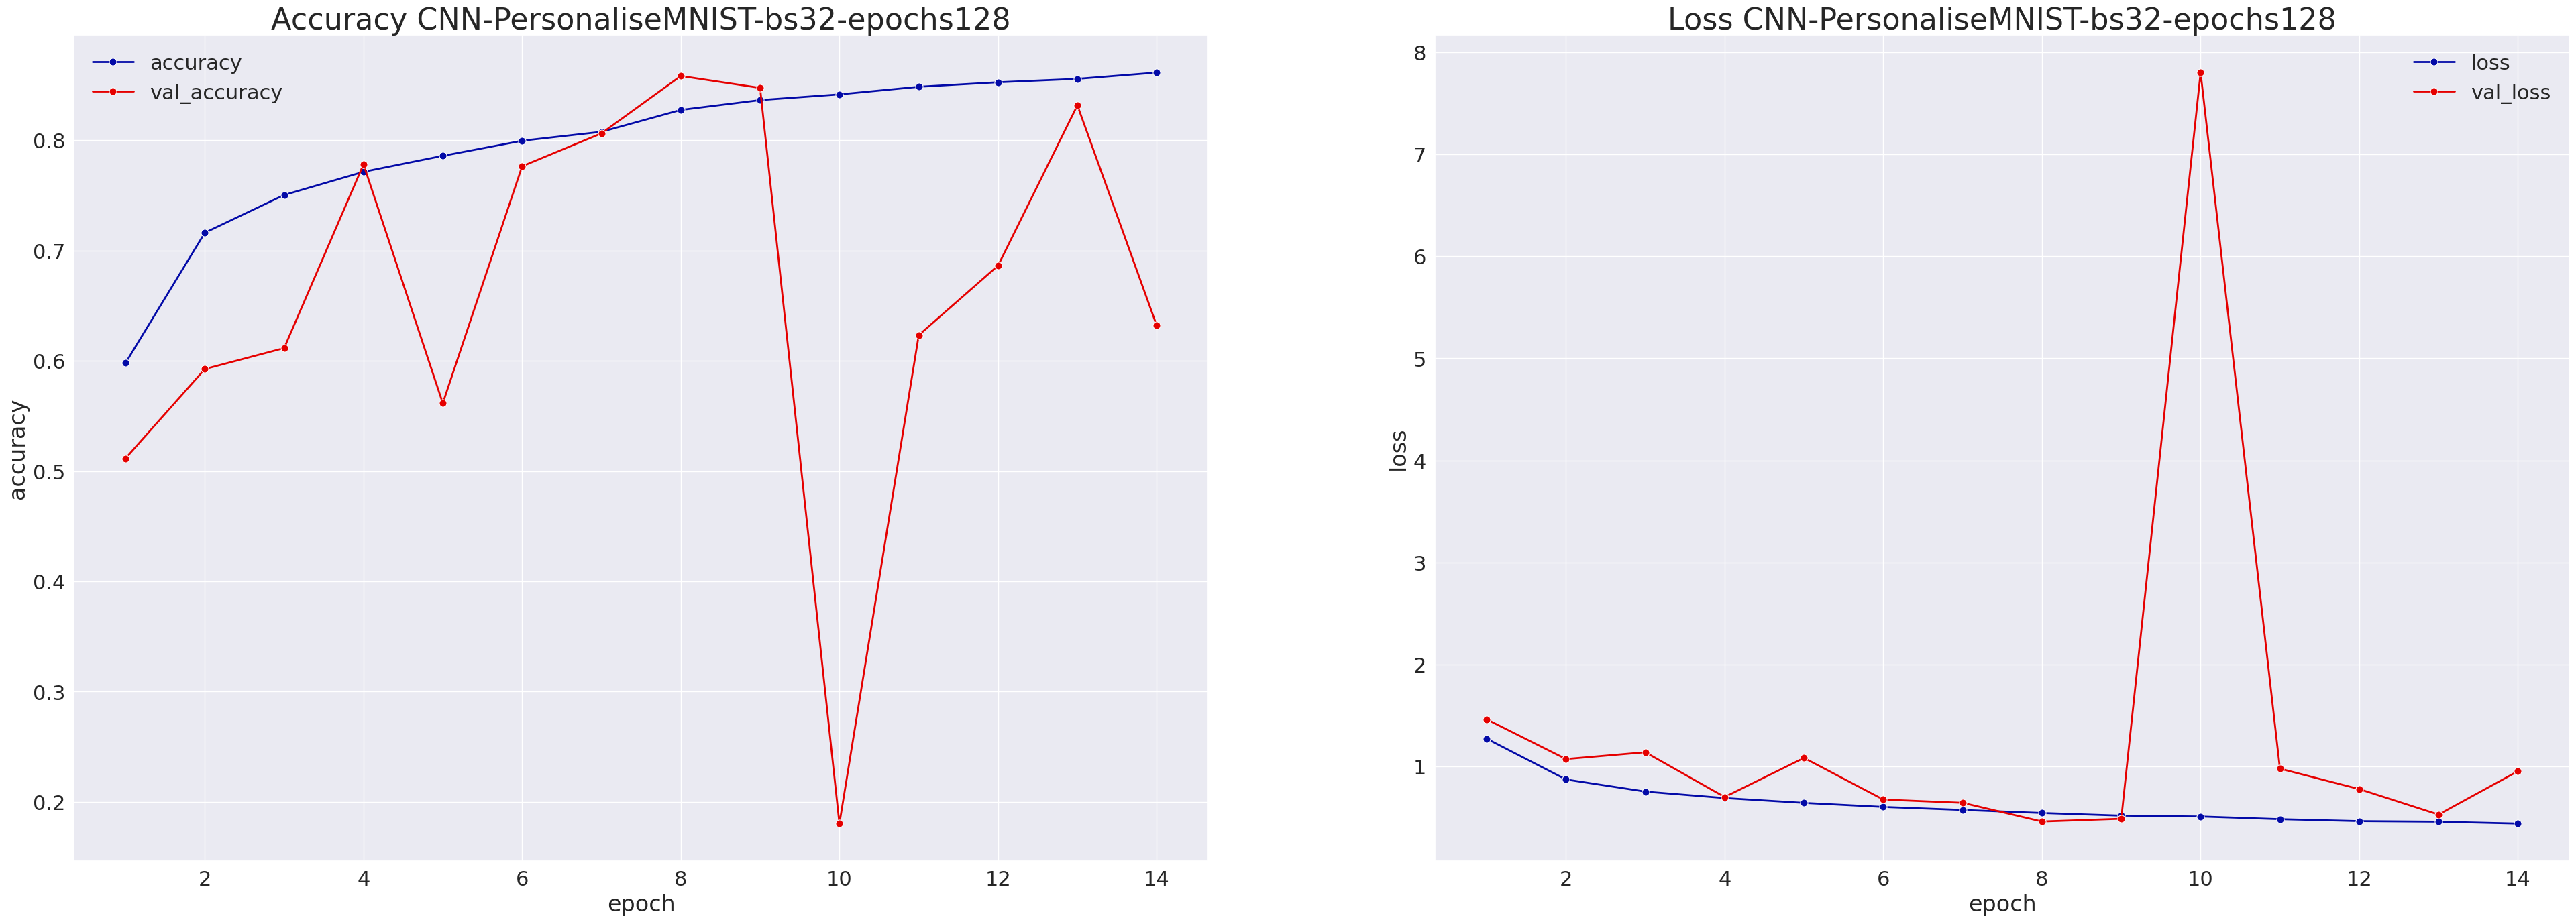

In [24]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [25]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [26]:
for i, (img,lab) in enumerate(pipelineValidation):
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [27]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

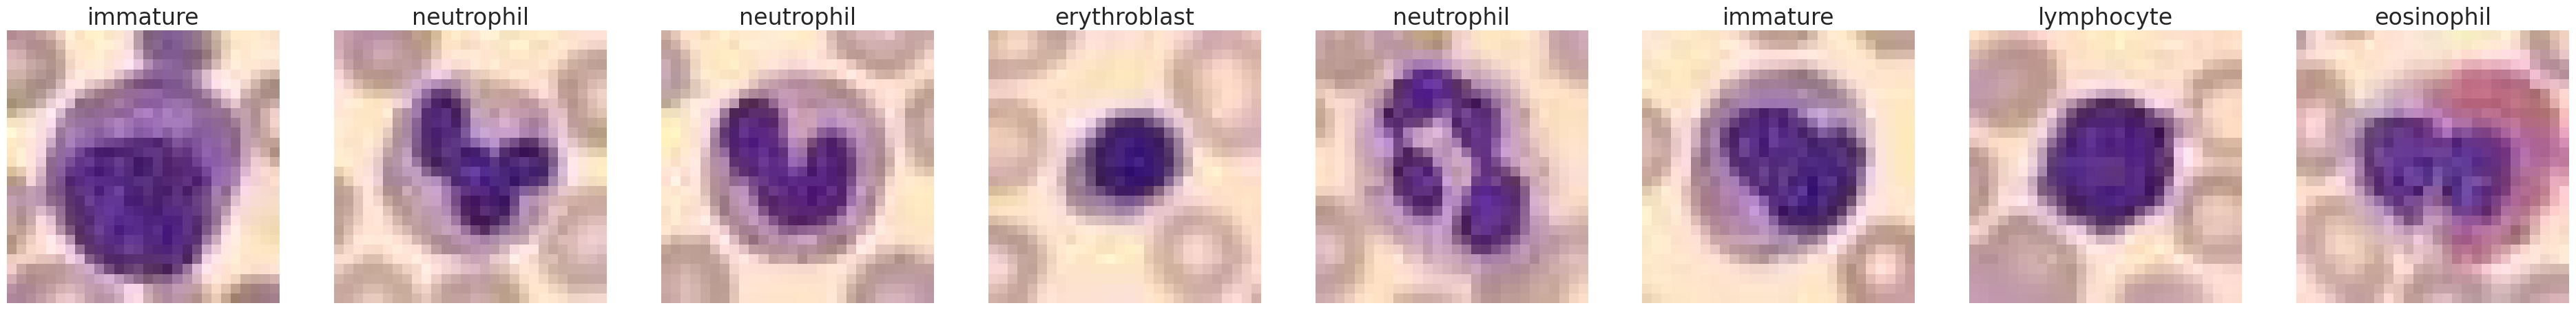

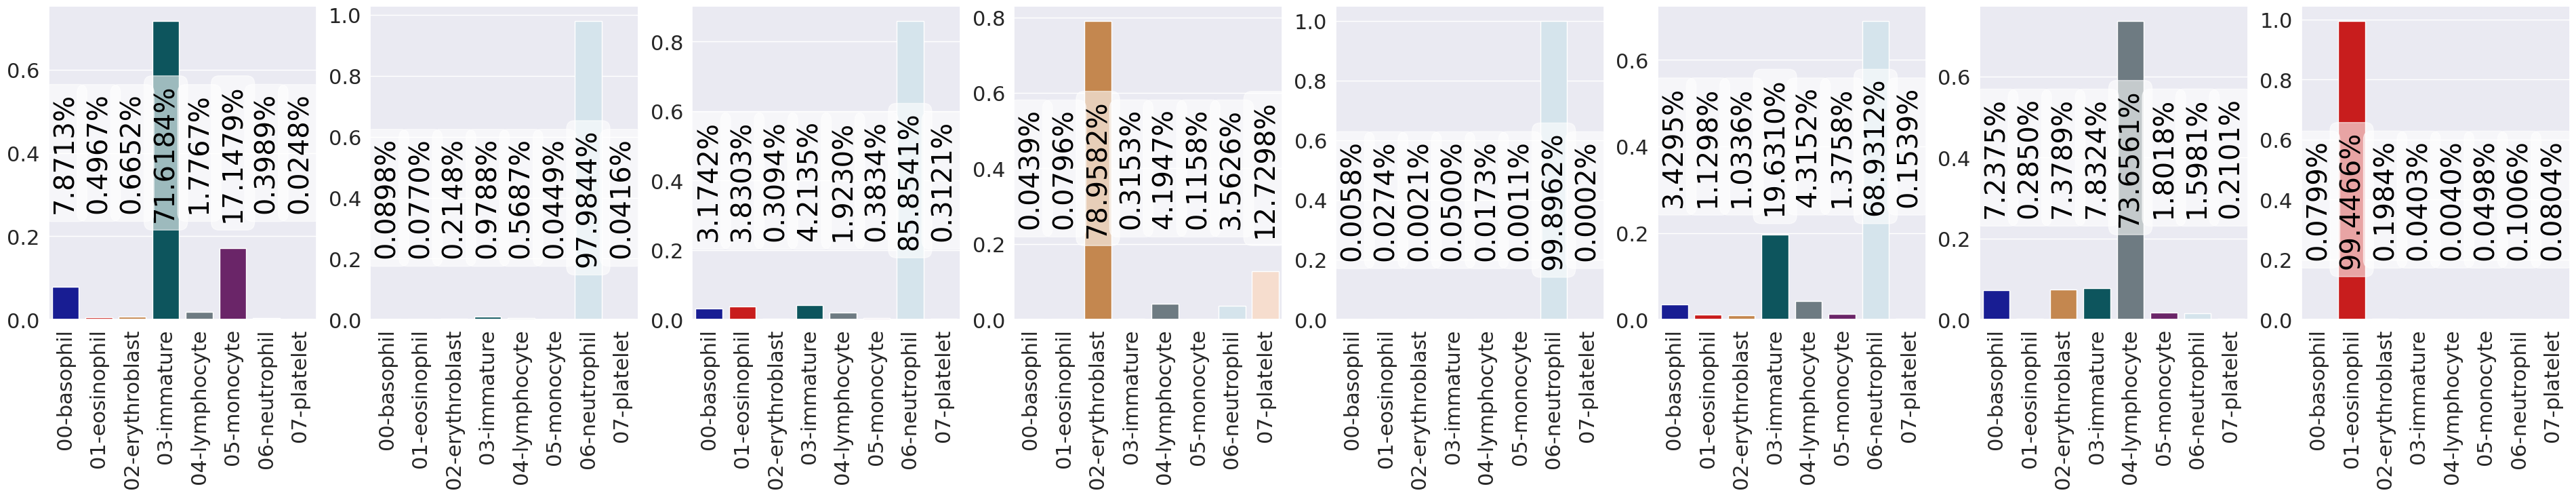

In [28]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

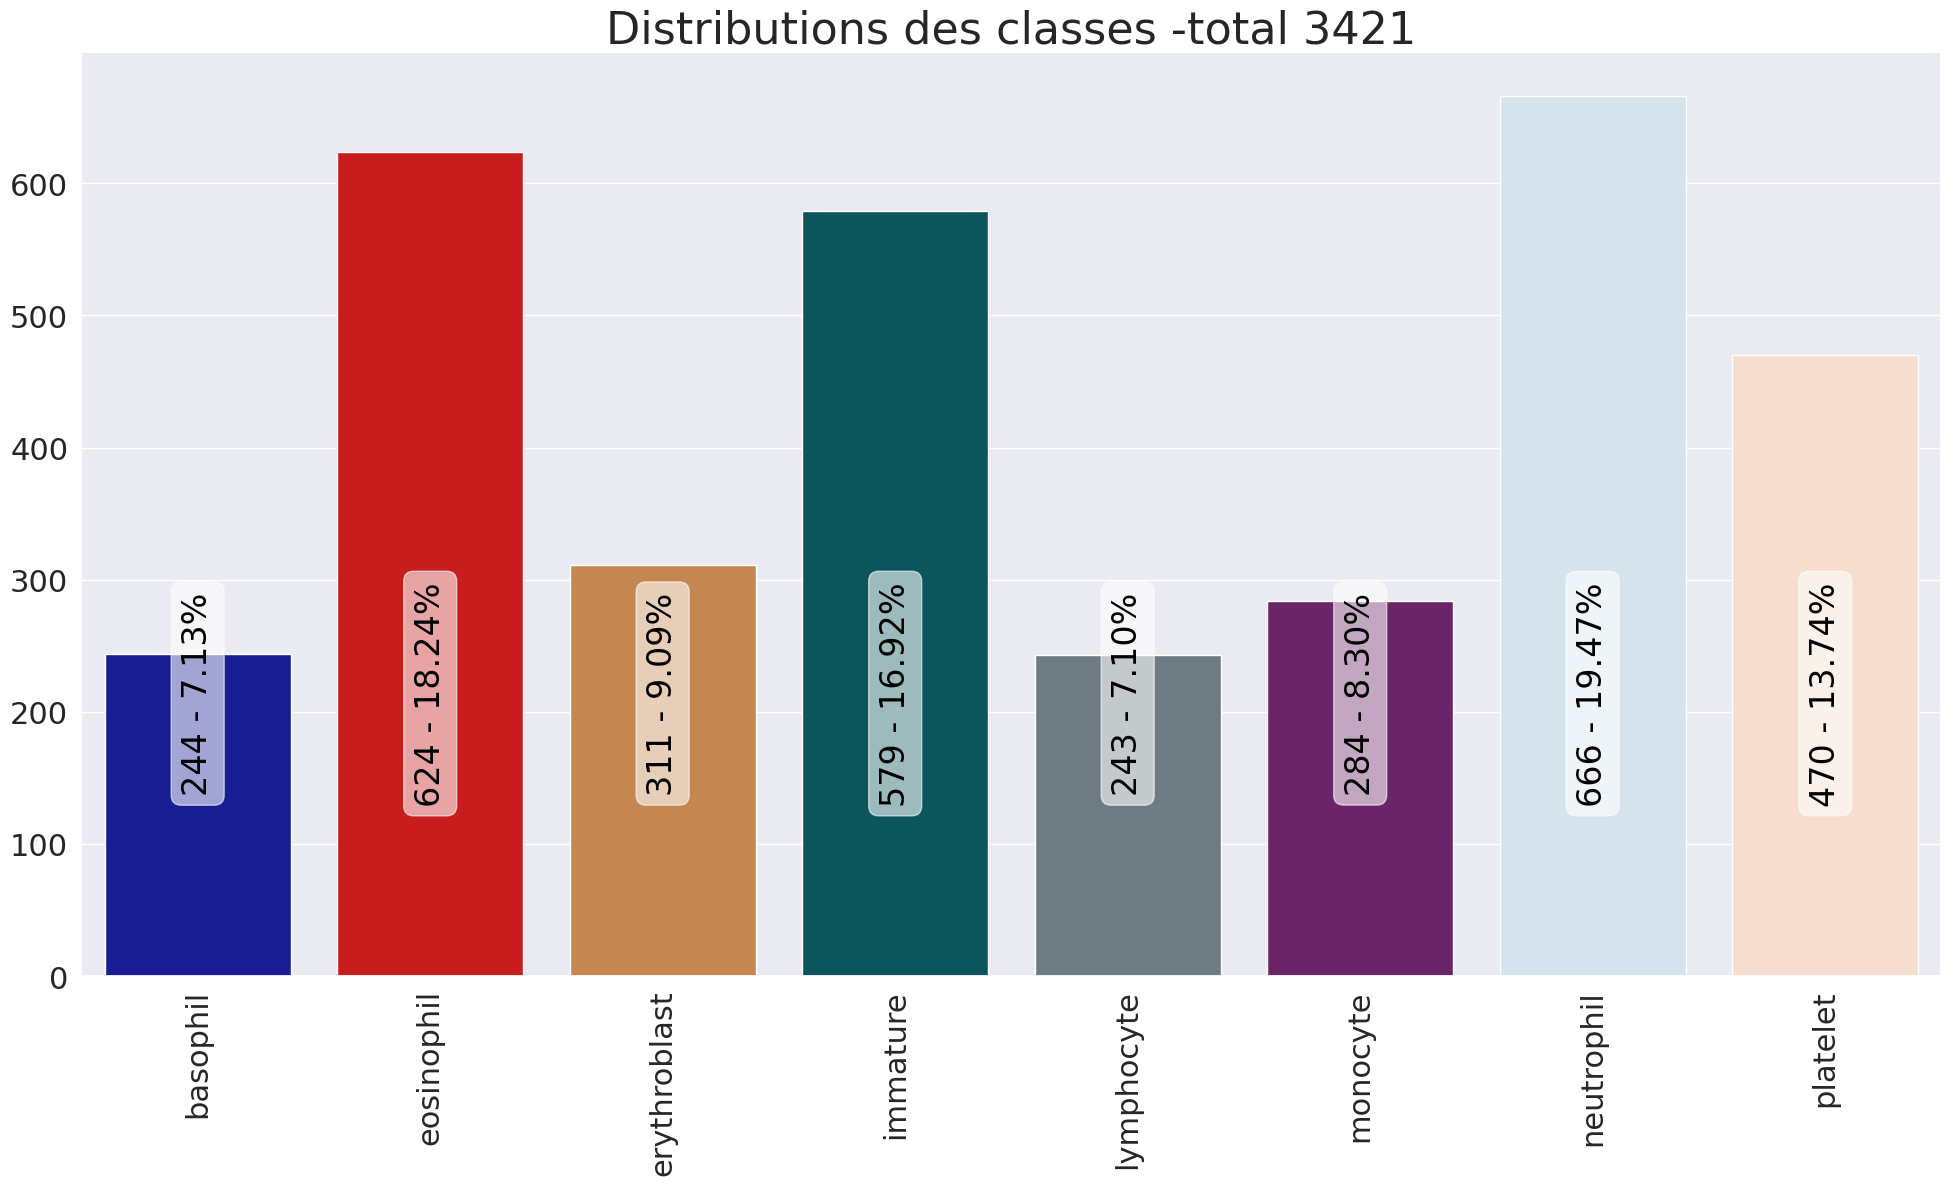

In [29]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

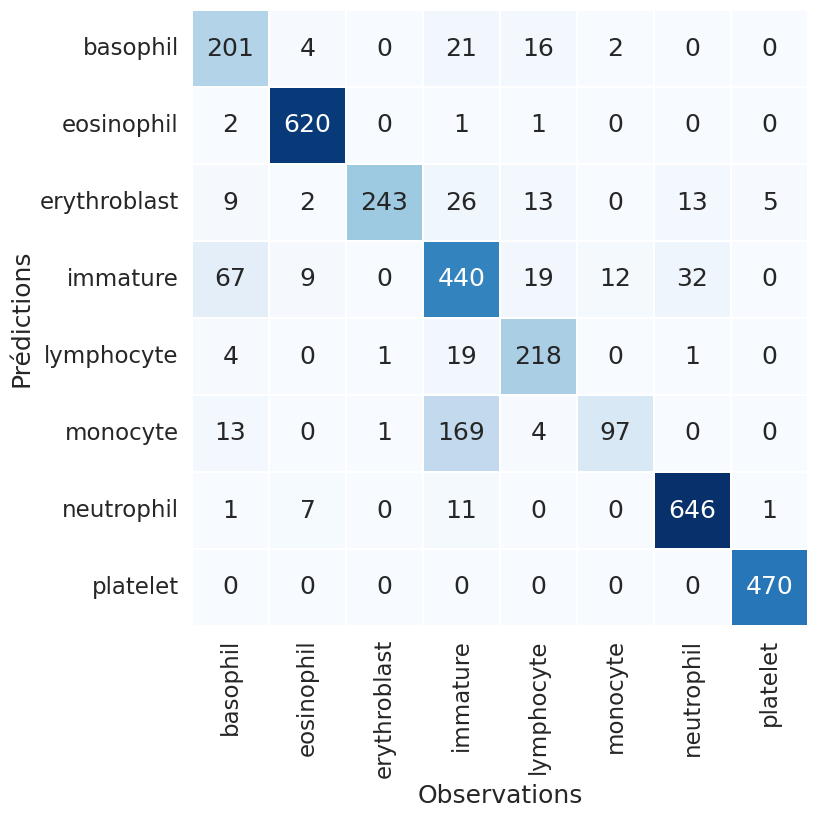

In [30]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Area under the ROC curve : 0.9781	--	Exécution  :5.61s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.978091,0.936850,0.851524,0.853659,0.857441,0.857936,0.870067,0.857936,2935,23461,486,486,3421,CNN-PersonaliseMNIST-bs32-epochs128
1,basophil,0.976865,0.748841,0.743068,0.789474,0.701816,0.959369,0.676768,0.823770,201,3081,96,43,244,CNN-PersonaliseMNIST-bs32-epochs128
2,eosinophil,0.999353,0.989906,0.979463,0.987890,0.971178,0.992400,0.965732,0.993590,620,2775,22,4,624,CNN-PersonaliseMNIST-bs32-epochs128
3,erythroblast,0.966207,0.924302,0.874101,0.815984,0.941131,0.979538,0.991837,0.781350,243,3108,2,68,311,CNN-PersonaliseMNIST-bs32-epochs128
4,immature,0.928677,0.695674,0.695103,0.732601,0.661256,0.887167,0.640466,0.759931,440,2595,247,139,579,CNN-PersonaliseMNIST-bs32-epochs128
5,lymphocyte,0.994014,0.939485,0.848249,0.876911,0.821402,0.977200,0.804428,0.897119,218,3125,53,25,243,CNN-PersonaliseMNIST-bs32-epochs128
6,monocyte,0.963234,0.765878,0.491139,0.388933,0.666209,0.941245,0.873874,0.341549,97,3123,14,187,284,CNN-PersonaliseMNIST-bs32-epochs128
7,neutrophil,0.996386,0.990594,0.951399,0.962455,0.940594,0.980707,0.933526,0.969970,646,2709,46,20,666,CNN-PersonaliseMNIST-bs32-epochs128
8,platelet,0.999996,0.999977,0.993658,0.997453,0.989890,0.998246,0.987395,1.000000,470,2945,6,0,470,CNN-PersonaliseMNIST-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

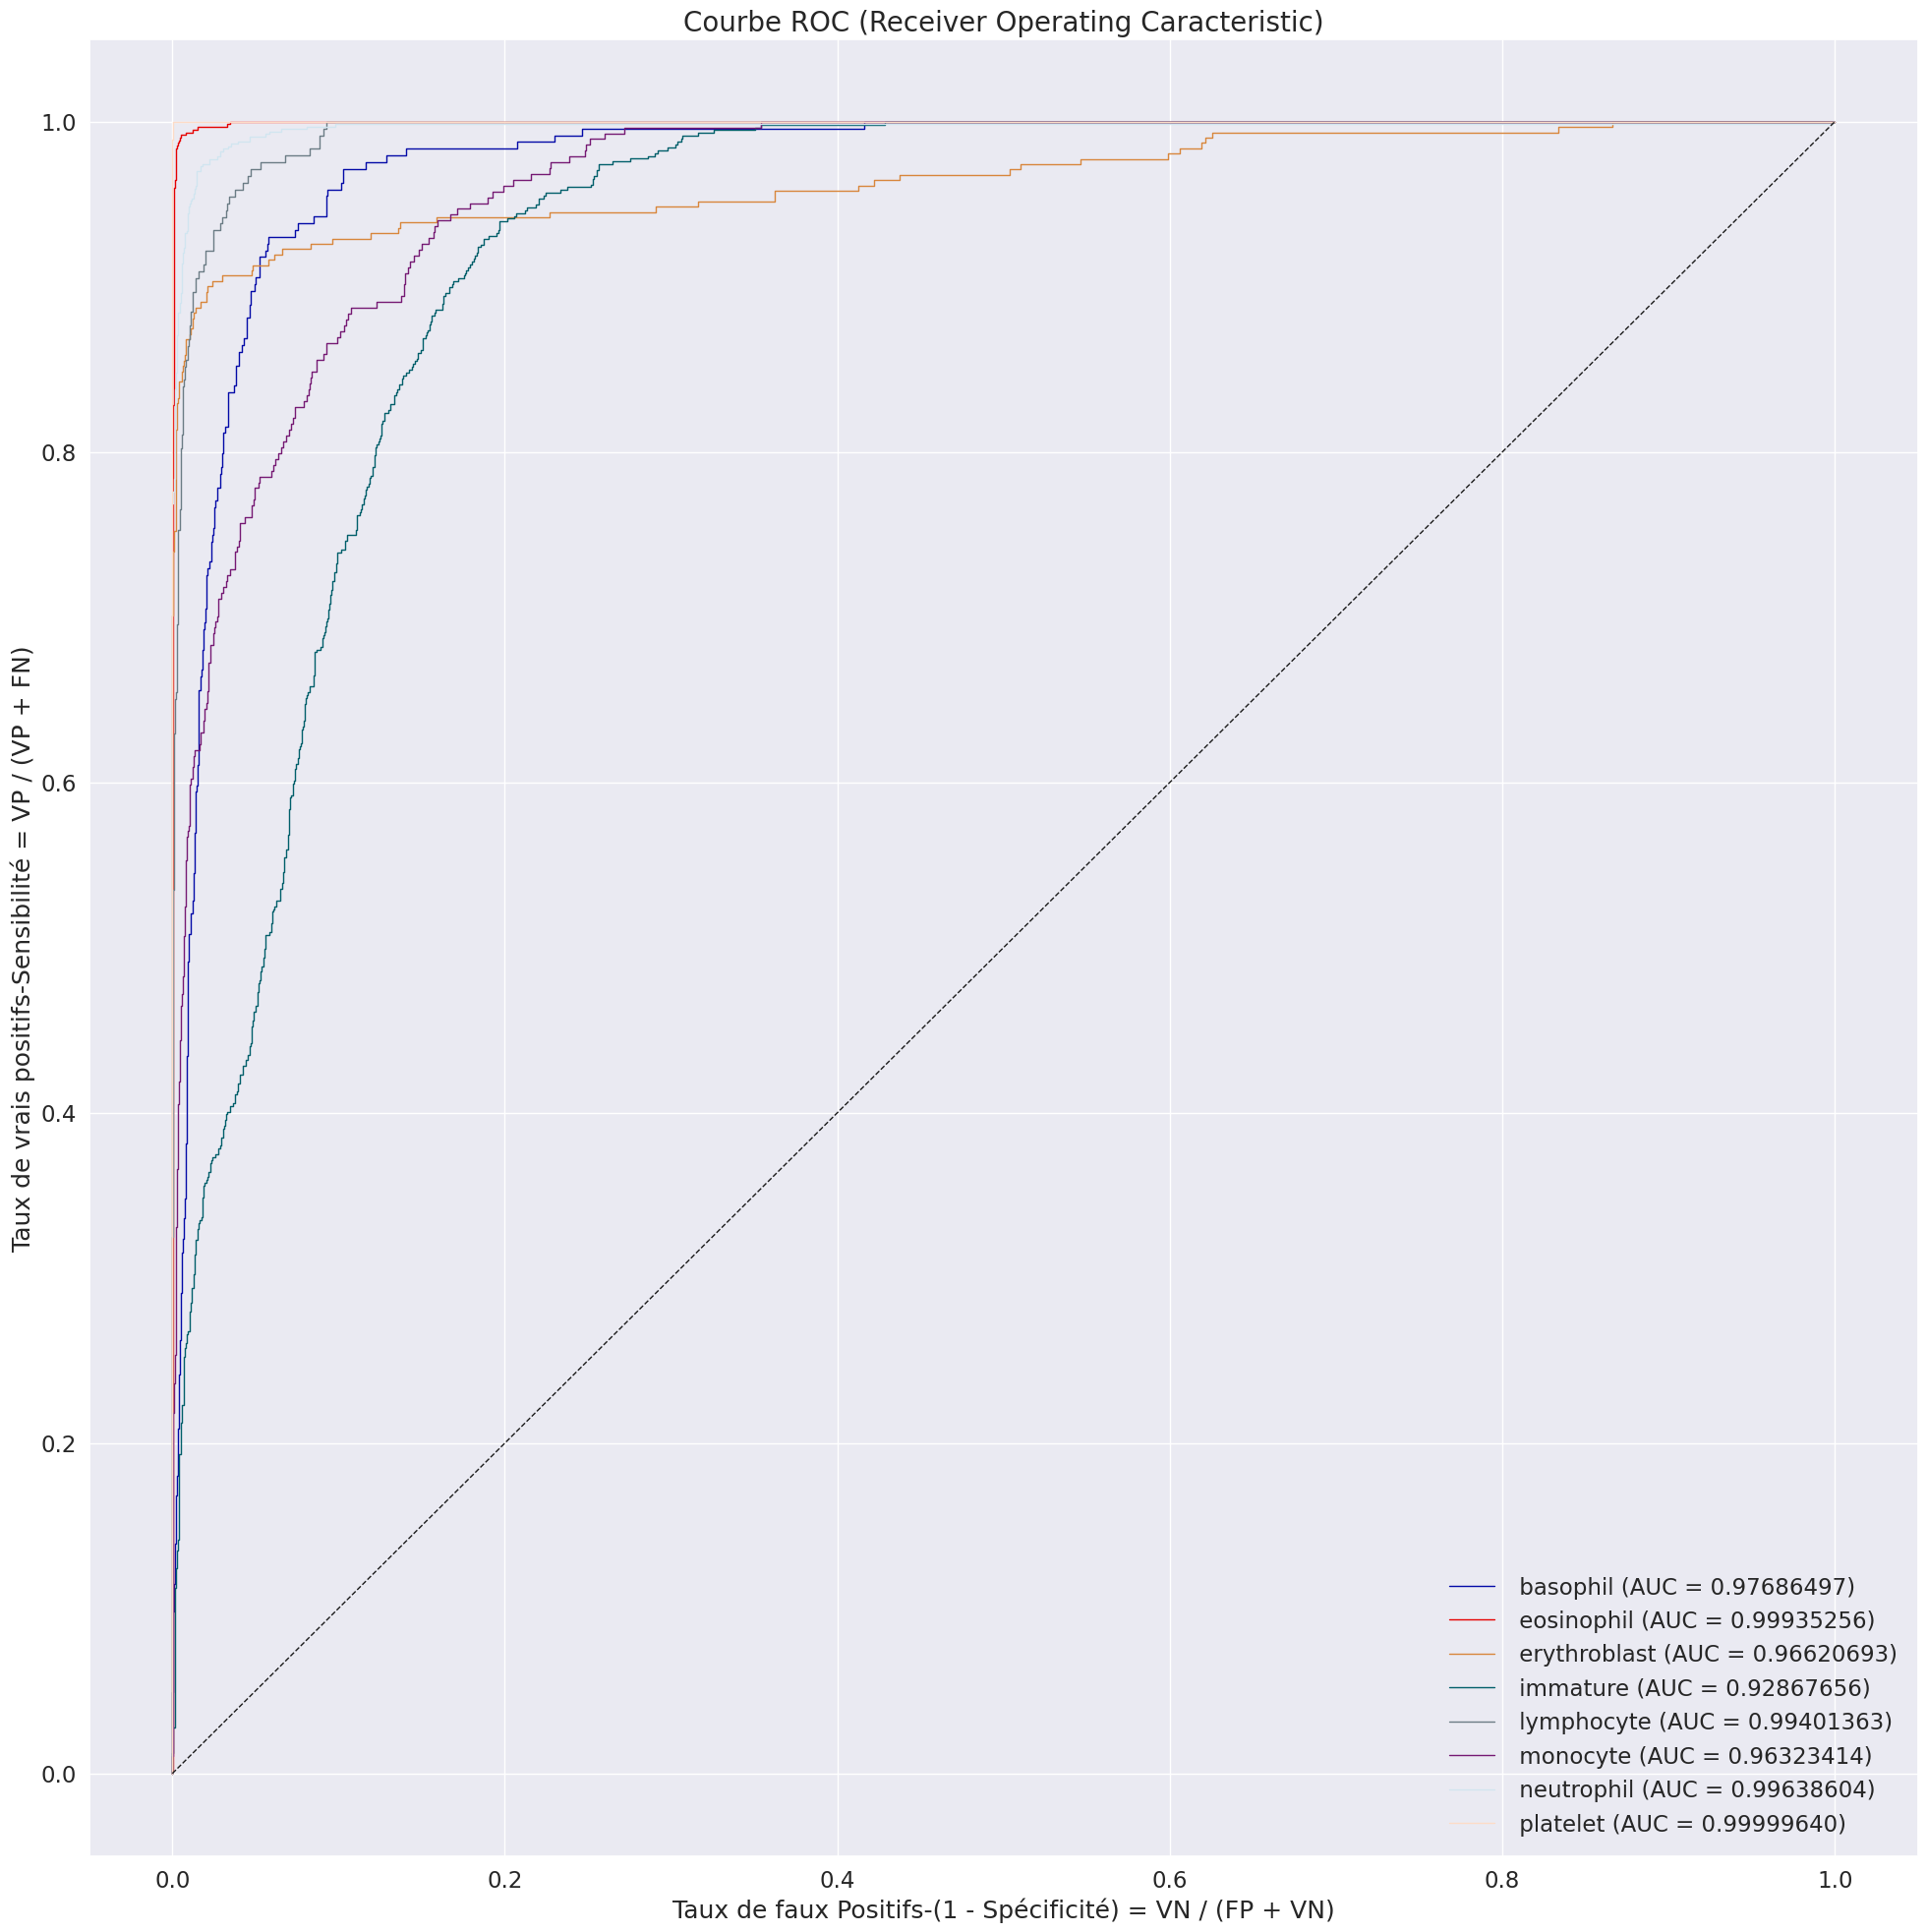

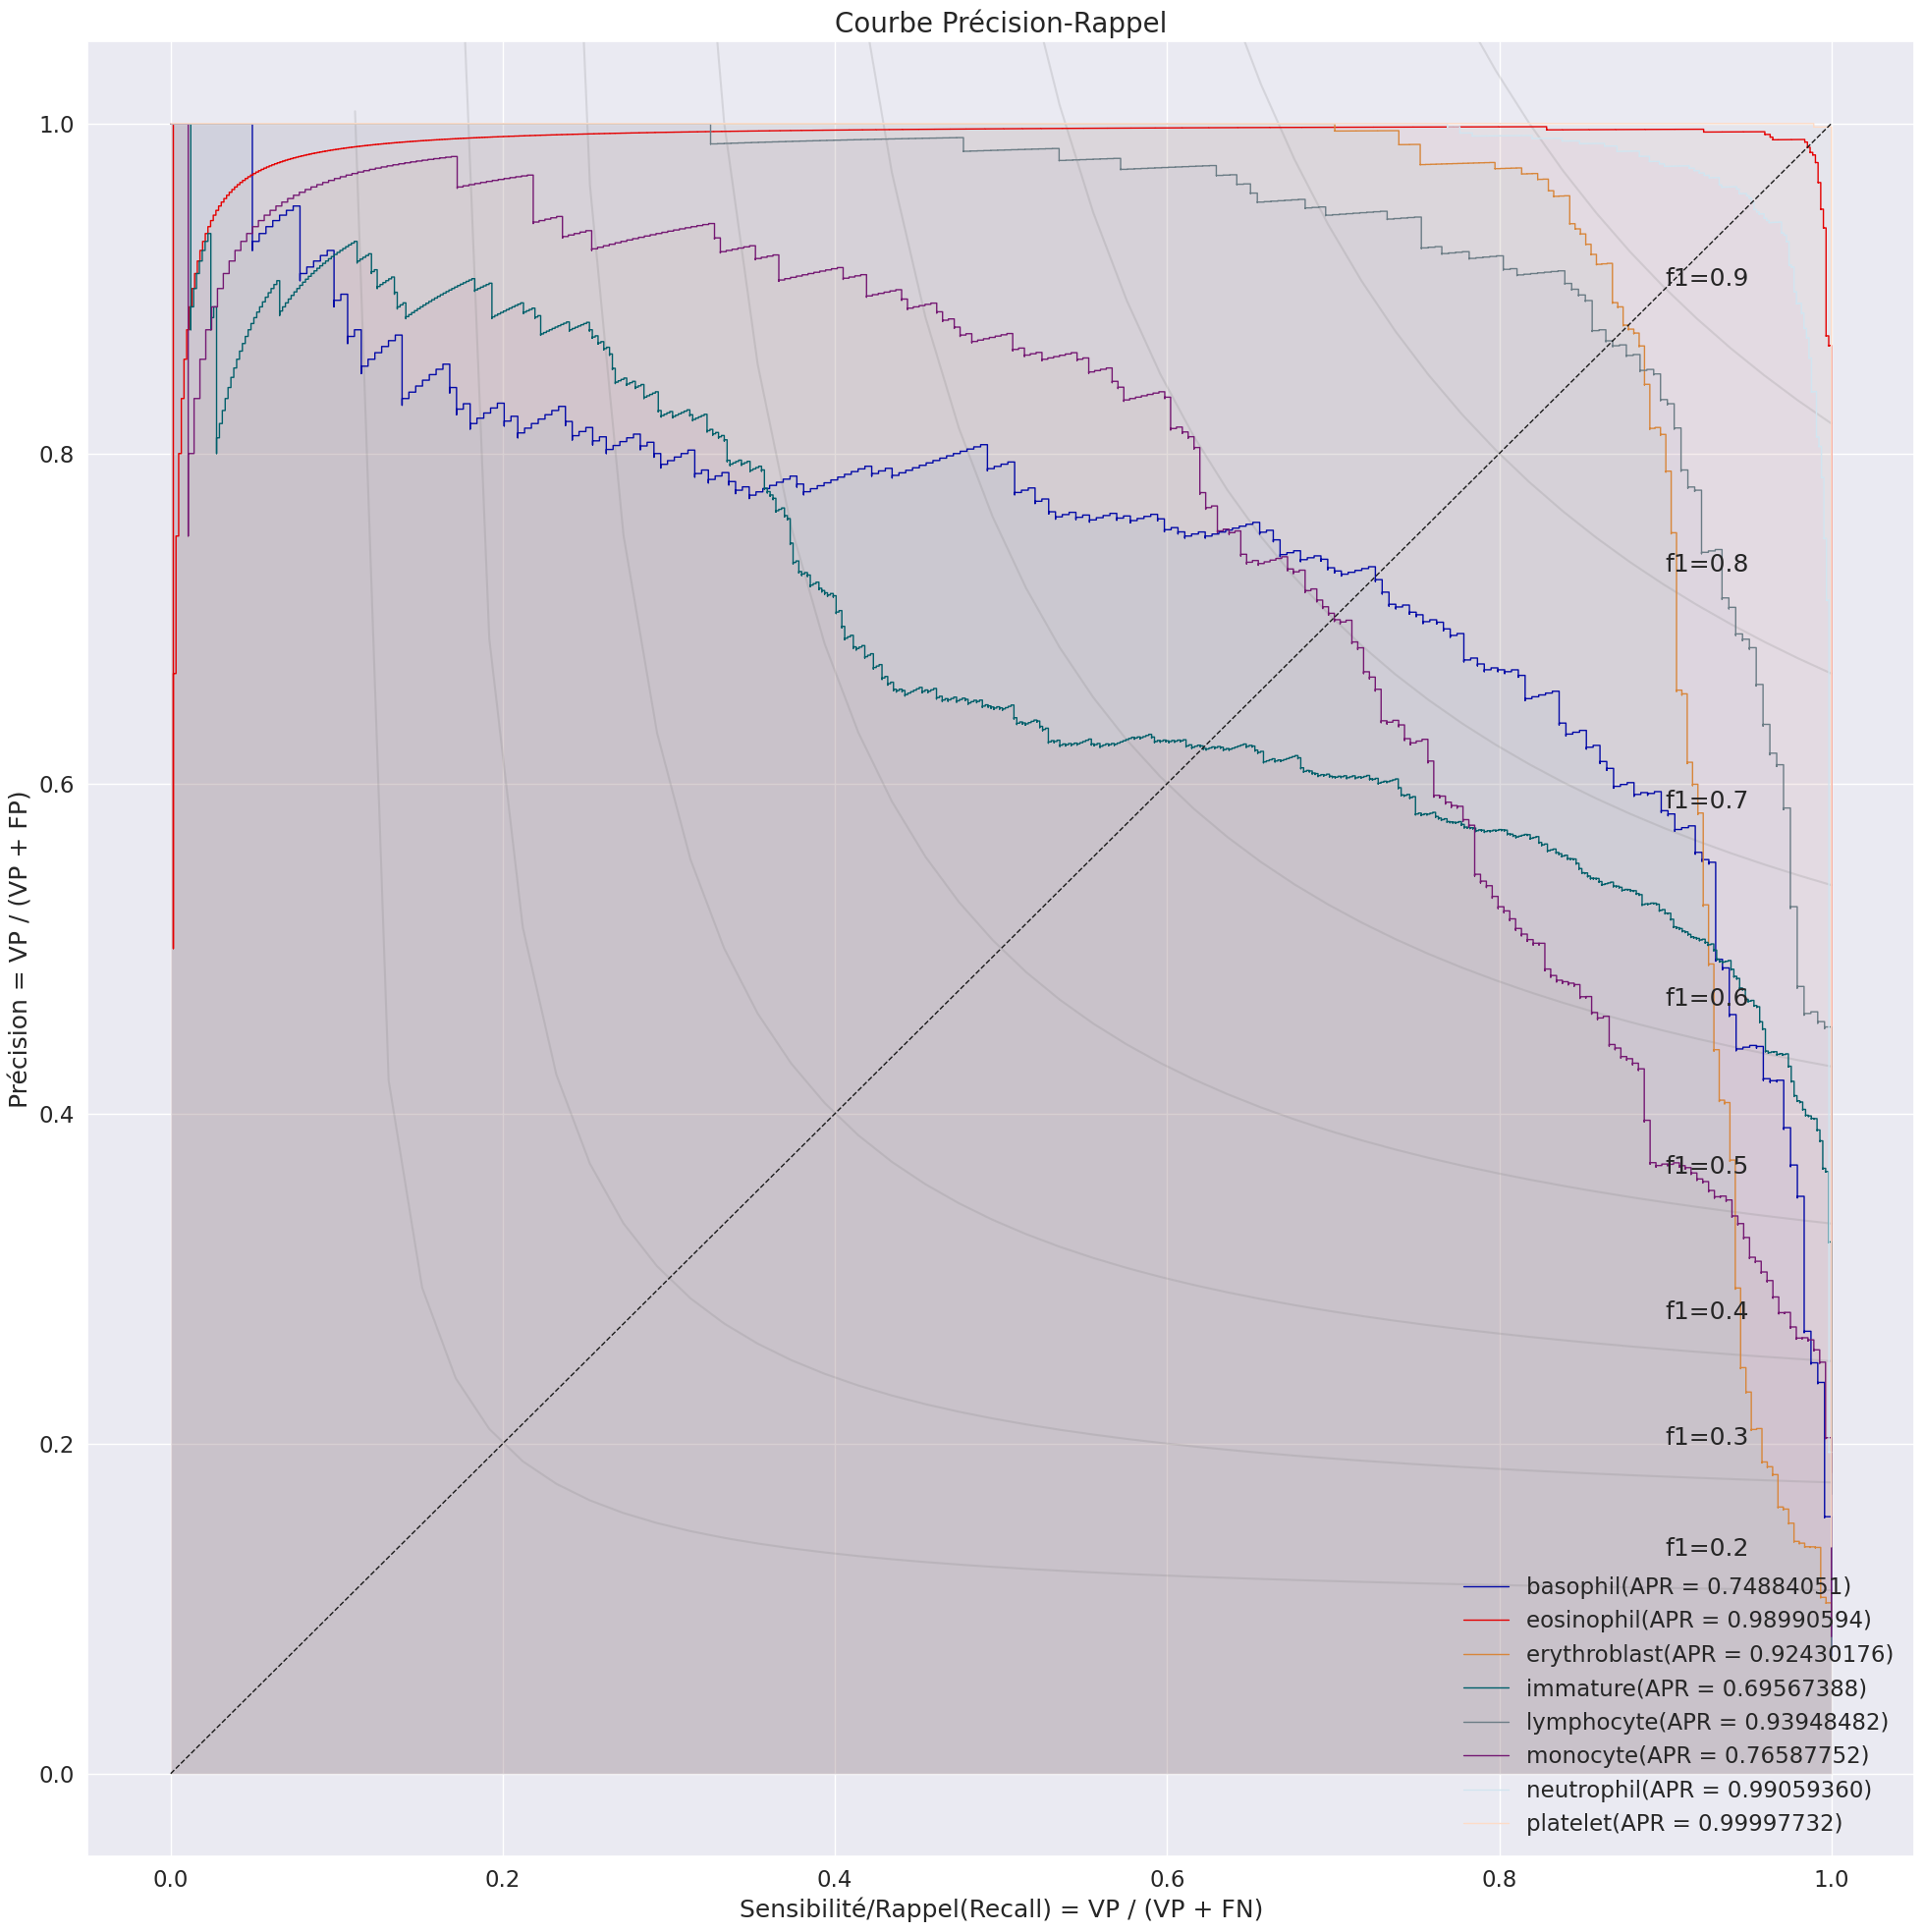

In [31]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette,
                                                  repertoireEnregistrement=repertoireEnregistrement,
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats